# 3PA Ablation Study Analysis

This notebook analyzes the ablation study results for the 3PA (Physical Projector-based Adversarial Attack) method.
We compare different parameter configurations:
- **Patch sizes**: 4x4, 8x8, 16x16, 32x32
- **Rejuvenation**: with vs without
- **Simulation**: with vs without

All experiments are on a single scene (mailbag) with the same viewing angles and distances.

**Note**: Classification is performed using a single MobileNet model for all approaches.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Experiment paths
EXPERIMENT_PATH = r"C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33"
DATA_PATH = os.path.join(EXPERIMENT_PATH, 'data')

# Additional experiment for single viewpoint
SINGLE_VP_EXPERIMENT_PATH = r"C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_19_26_39"
SINGLE_VP_DATA_PATH = os.path.join(SINGLE_VP_EXPERIMENT_PATH, 'data')

# Ablation configurations - different 3PA parameter variations
ABLATION_CONFIGS = {
    'Baseline': {
        'display_name': 'No Attack',
        'color': '#bdc3c7',
        'description': 'No projection (original scene)',
        'is_baseline': True
    },
    'Baseline_Noise': {
        'display_name': 'Random Noise',
        'color': '#95a5a6',
        'description': 'Random noise projection',
        'is_baseline': True
    },
    'Patch_4': {
        'display_name': '3PA (4×4)',
        'color': '#3498db',
        'description': '4×4 patch grid',
        'is_baseline': False
    },
    'Patch_8': {
        'display_name': '3PA (8×8)',
        'color': '#9b59b6',
        'description': '8×8 patch grid',
        'is_baseline': False
    },
    'Patch_16_rejuv': {
        'display_name': '3PA (16×16)',
        'color': '#27ae60',
        'description': '16×16 patch grid with rejuvenation (default)',
        'is_baseline': False
    },
    'Patch_16_no_rejuv_orig': {
        'display_name': '3PA (16×16, no rejuv)',
        'color': '#e67e22',
        'description': '16×16 patch grid without rejuvenation',
        'is_baseline': False
    },
    'Patch_16_no_sim': {
        'display_name': '3PA (16×16, no sim)',
        'color': '#e74c3c',
        'description': '16×16 patch grid without simulation',
        'is_baseline': False
    },
    'Patch_32': {
        'display_name': '3PA (32×32)',
        'color': '#1abc9c',
        'description': '32×32 patch grid',
        'is_baseline': False
    },
    'Patch_16_single_vp': {
        'display_name': '3PA (16×16, single VP)',
        'color': '#f39c12',
        'description': '16×16 patch grid optimized from single viewpoint',
        'is_baseline': False
    }
}

# Order for display (baselines first, then 3PA methods)
BASELINE_ORDER = ['Baseline', 'Baseline_Noise']
PATCH_ORDER = ['Patch_4', 'Patch_8', 'Patch_16_rejuv', 'Patch_16_no_rejuv_orig', 
               'Patch_16_no_sim', 'Patch_32', 'Patch_16_single_vp']
DISPLAY_ORDER = BASELINE_ORDER + PATCH_ORDER

print(f"Main experiment path: {EXPERIMENT_PATH}")
print(f"Single VP experiment path: {SINGLE_VP_EXPERIMENT_PATH}")
print(f"Classifier: MobileNet (single model for all approaches)")
print(f"\nAblation configurations:")
for key, config in ABLATION_CONFIGS.items():
    print(f"  - {config['display_name']}: {config['description']}")

Main experiment path: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33
Single VP experiment path: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_19_26_39
Classifier: MobileNet (single model for all approaches)

Ablation configurations:
  - No Attack: No projection (original scene)
  - Random Noise: Random noise projection
  - 3PA (4×4): 4×4 patch grid
  - 3PA (8×8): 8×8 patch grid
  - 3PA (16×16): 16×16 patch grid with rejuvenation (default)
  - 3PA (16×16, no rejuv): 16×16 patch grid without rejuvenation
  - 3PA (16×16, no sim): 16×16 patch grid without simulation
  - 3PA (32×32): 32×32 patch grid
  - 3PA (16×16, single VP): 16×16 patch grid optimized from single viewpoint


In [33]:
def load_predictions_data():
    """Load raw predictions data from both experiments and merge"""
    # Load main experiment
    pred_path = os.path.join(DATA_PATH, 'raw_predictions.csv')
    
    if not os.path.exists(pred_path):
        print(f"Error: {pred_path} not found")
        return None
    
    df_main = pd.read_csv(pred_path)
    print(f"Loaded {len(df_main)} predictions from main experiment")
    print(f"  Approaches: {df_main['approach'].unique()}")
    
    # Load single VP experiment
    single_vp_path = os.path.join(SINGLE_VP_DATA_PATH, 'raw_predictions.csv')
    
    if os.path.exists(single_vp_path):
        df_single_vp = pd.read_csv(single_vp_path)
        print(f"\nLoaded {len(df_single_vp)} predictions from single VP experiment")
        print(f"  Approaches: {df_single_vp['approach'].unique()}")
        
        # Only take the Patch_16_single_vp approach from single VP experiment
        df_single_vp_filtered = df_single_vp[df_single_vp['approach'] == 'Patch_16_single_vp']
        print(f"  Filtered to {len(df_single_vp_filtered)} single VP records")
        
        # Merge datasets
        df = pd.concat([df_main, df_single_vp_filtered], ignore_index=True)
    else:
        print(f"Warning: Single VP experiment not found at {single_vp_path}")
        df = df_main
    
    print(f"\nTotal combined: {len(df)} predictions")
    print(f"All approaches: {df['approach'].unique()}")
    
    return df

def load_pixel_change_data():
    """Load pixel change analysis data from both experiments"""
    pixel_data = {}
    pixel_se_data = {}
    
    # Load main experiment
    pixel_path = os.path.join(DATA_PATH, 'pixel_change_analysis.csv')
    
    if os.path.exists(pixel_path):
        df = pd.read_csv(pixel_path)
        print(f"Loaded {len(df)} pixel change entries from main experiment")
        
        for approach in df['approach'].unique():
            approach_df = df[df['approach'] == approach]
            pixel_data[approach] = approach_df['pixel_change_pct'].mean()
            n = len(approach_df)
            if n > 1:
                pixel_se_data[approach] = approach_df['pixel_change_pct'].std(ddof=1) / np.sqrt(n)
            else:
                pixel_se_data[approach] = 0.0
    else:
        print(f"Warning: {pixel_path} not found")
    
    # Load single VP experiment pixel data
    single_vp_pixel_path = os.path.join(SINGLE_VP_DATA_PATH, 'pixel_change_analysis.csv')
    
    if os.path.exists(single_vp_pixel_path):
        df_single = pd.read_csv(single_vp_pixel_path)
        print(f"Loaded {len(df_single)} pixel change entries from single VP experiment")
        
        if 'Patch_16_single_vp' in df_single['approach'].unique():
            approach_df = df_single[df_single['approach'] == 'Patch_16_single_vp']
            pixel_data['Patch_16_single_vp'] = approach_df['pixel_change_pct'].mean()
            n = len(approach_df)
            if n > 1:
                pixel_se_data['Patch_16_single_vp'] = approach_df['pixel_change_pct'].std(ddof=1) / np.sqrt(n)
            else:
                pixel_se_data['Patch_16_single_vp'] = 0.0
    else:
        print(f"Warning: Single VP pixel data not found at {single_vp_pixel_path}")
    
    # Baseline has 0% pixel change
    pixel_data['Baseline'] = 0.0
    pixel_se_data['Baseline'] = 0.0
    
    return pixel_data, pixel_se_data

# Load data
print("Loading experiment data...\n")
predictions_df = load_predictions_data()
pixel_data, pixel_se_data = load_pixel_change_data()

print(f"\nPixel change by approach:")
for approach in DISPLAY_ORDER:
    if approach in pixel_data:
        val = pixel_data[approach]
        se = pixel_se_data.get(approach, 0)
        print(f"  {ABLATION_CONFIGS[approach]['display_name']}: {val:.2f}% ± {se:.2f}%")

Loading experiment data...

Loaded 84000 predictions from main experiment
  Approaches: ['Baseline' 'Baseline_Noise' 'Patch_16_rejuv' 'Patch_16_no_rejuv_orig'
 'Patch_32' 'Patch_8' 'Patch_4' 'Patch_16_no_sim']

Loaded 21600 predictions from single VP experiment
  Approaches: ['Baseline' 'Baseline_Noise' 'Patch_16_single_vp']
  Filtered to 9600 single VP records

Total combined: 93600 predictions
All approaches: ['Baseline' 'Baseline_Noise' 'Patch_16_rejuv' 'Patch_16_no_rejuv_orig'
 'Patch_32' 'Patch_8' 'Patch_4' 'Patch_16_no_sim' 'Patch_16_single_vp']
Loaded 325 pixel change entries from main experiment
Loaded 65 pixel change entries from single VP experiment

Pixel change by approach:
  No Attack: 0.00% ± 0.00%
  Random Noise: 56.28% ± 1.08%
  3PA (4×4): 3.02% ± 0.27%
  3PA (8×8): 3.03% ± 0.27%
  3PA (16×16): 3.04% ± 0.26%
  3PA (16×16, no rejuv): 3.07% ± 0.26%
  3PA (16×16, no sim): 3.18% ± 0.27%
  3PA (32×32): 3.19% ± 0.27%
  3PA (16×16, single VP): 3.85% ± 0.41%


In [34]:
def calc_se(data):
    """Calculate standard error of the mean (returns percentage)"""
    if len(data) == 0:
        return np.nan
    return np.std(data, ddof=1) / np.sqrt(len(data)) * 100

def build_ablation_table(df, approaches, pixel_data=None, pixel_se_data=None):
    """Build ablation table with success rates and standard errors"""
    results = []
    
    for approach in approaches:
        if approach not in df['approach'].unique():
            continue
        
        approach_df = df[df['approach'] == approach]
        config = ABLATION_CONFIGS.get(approach, {})
        
        # Calculate overall success rate for this approach
        success_rate = approach_df['success'].mean() * 100
        success_se = calc_se(approach_df['success'])
        n_samples = len(approach_df)
        
        row = {
            'Method': approach,
            'Display_Name': config.get('display_name', approach),
            'Success_Rate': success_rate,
            'Success_SE': success_se,
            'N_Samples': n_samples
        }
        
        # Pixel change percentage
        if pixel_data and approach in pixel_data:
            row['Pixel%'] = pixel_data[approach]
            row['Pixel_SE'] = pixel_se_data.get(approach, 0) if pixel_se_data else 0
        else:
            row['Pixel%'] = np.nan
            row['Pixel_SE'] = np.nan
        
        results.append(row)
    
    return pd.DataFrame(results)

# Build ablation table
ablation_table = build_ablation_table(predictions_df, DISPLAY_ORDER, pixel_data, pixel_se_data)

# Display summary
print("\n" + "="*80)
print("ABLATION STUDY RESULTS")
print("="*80)
print(f"\n{'Configuration':<30} {'Success Rate':<20} {'Pixel Change':<20} {'Samples':<10}")
print("-"*80)

for _, row in ablation_table.iterrows():
    name = row['Display_Name']
    sr = f"{row['Success_Rate']:.1f}% ± {row['Success_SE']:.1f}%"
    px = f"{row['Pixel%']:.2f}% ± {row['Pixel_SE']:.2f}%" if not pd.isna(row['Pixel%']) else "N/A"
    n = int(row['N_Samples'])
    print(f"{name:<30} {sr:<20} {px:<20} {n:<10}")


ABLATION STUDY RESULTS

Configuration                  Success Rate         Pixel Change         Samples   
--------------------------------------------------------------------------------
No Attack                      0.0% ± 0.0%          0.00% ± 0.00%        6000      
Random Noise                   41.6% ± 0.6%         56.28% ± 1.08%       6000      
3PA (4×4)                      13.1% ± 0.3%         3.02% ± 0.27%        12000     
3PA (8×8)                      72.9% ± 0.4%         3.03% ± 0.27%        12000     
3PA (16×16)                    99.5% ± 0.1%         3.04% ± 0.26%        12000     
3PA (16×16, no rejuv)          97.5% ± 0.1%         3.07% ± 0.26%        12000     
3PA (16×16, no sim)            14.1% ± 0.3%         3.18% ± 0.27%        12000     
3PA (32×32)                    89.0% ± 0.3%         3.19% ± 0.27%        12000     
3PA (16×16, single VP)         2.6% ± 0.2%          3.85% ± 0.41%        9600      


Figures will be saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures
Sorted display order (3PA by success rate, highest first):
  1. No Attack: 0.0%
  2. Random Noise: 41.6%
  3. 3PA (16×16): 99.5%
  4. 3PA (16×16, no rejuv): 97.5%
  5. 3PA (32×32): 89.0%
  6. 3PA (8×8): 72.9%
  7. 3PA (16×16, no sim): 14.1%
  8. 3PA (4×4): 13.1%
  9. 3PA (16×16, single VP): 2.6%


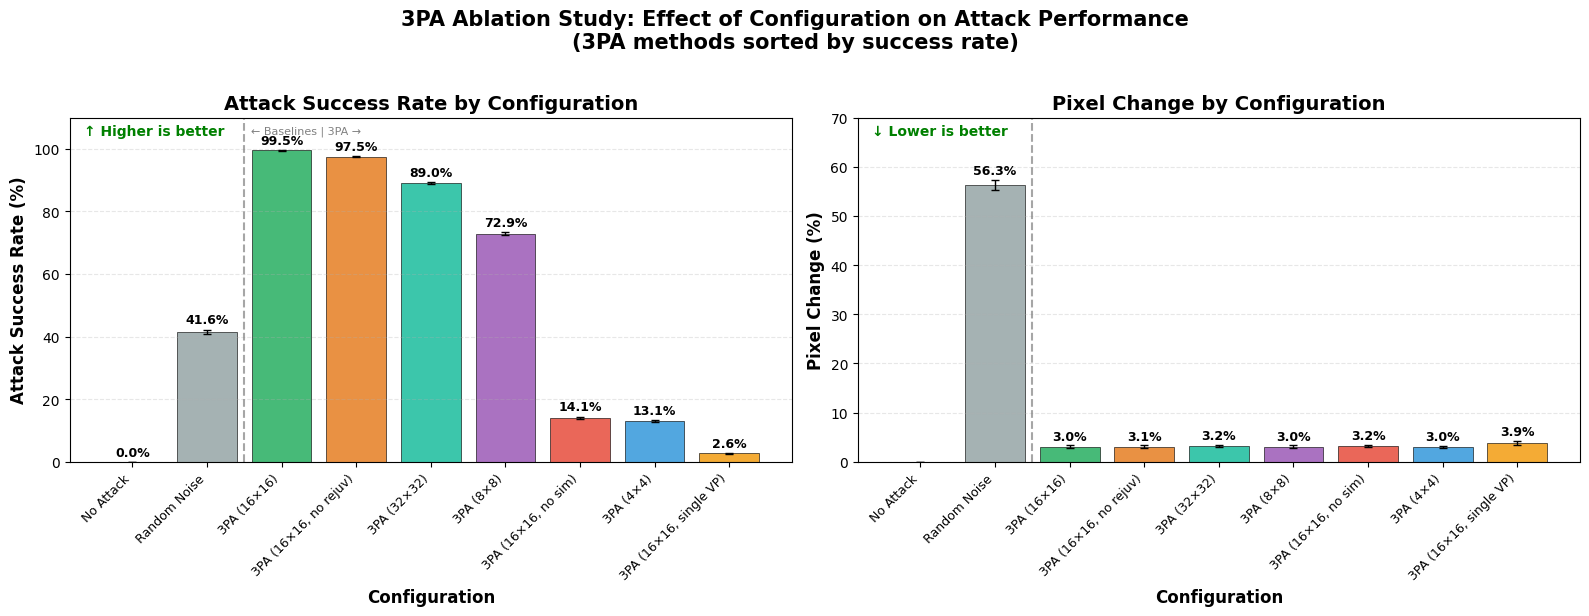


Chart saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\ablation_comparison.png


In [35]:
# Create output directory for figures
FIGURES_PATH = os.path.join(EXPERIMENT_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)
print(f"Figures will be saved to: {FIGURES_PATH}")

# Create sorted display order: baselines first, then 3PA methods sorted by success rate (highest to lowest)
def get_sorted_display_order(ablation_table, baseline_order, patch_order):
    """Sort 3PA methods by success rate (highest first), keep baselines at beginning"""
    # Get 3PA methods with their success rates
    patch_data = []
    for approach in patch_order:
        row = ablation_table[ablation_table['Method'] == approach]
        if len(row) > 0:
            patch_data.append({
                'approach': approach,
                'success_rate': row.iloc[0]['Success_Rate']
            })
    
    # Sort patches by success rate (highest to lowest)
    patch_data_sorted = sorted(patch_data, key=lambda x: x['success_rate'], reverse=True)
    sorted_patches = [p['approach'] for p in patch_data_sorted]
    
    # Combine: baselines first, then sorted patches
    sorted_order = [b for b in baseline_order if b in ablation_table['Method'].values] + sorted_patches
    return sorted_order

SORTED_DISPLAY_ORDER = get_sorted_display_order(ablation_table, BASELINE_ORDER, PATCH_ORDER)
print(f"Sorted display order (3PA by success rate, highest first):")
for i, approach in enumerate(SORTED_DISPLAY_ORDER):
    row = ablation_table[ablation_table['Method'] == approach]
    if len(row) > 0:
        sr = row.iloc[0]['Success_Rate']
        print(f"  {i+1}. {ABLATION_CONFIGS[approach]['display_name']}: {sr:.1f}%")

# Main comparison: Success Rate and Pixel Change
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get data in sorted display order
configs = []
success_rates = []
success_errors = []
pixel_pcts = []
pixel_errors = []
colors = []

for approach in SORTED_DISPLAY_ORDER:
    row = ablation_table[ablation_table['Method'] == approach]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    
    configs.append(ABLATION_CONFIGS[approach]['display_name'])
    success_rates.append(row['Success_Rate'])
    success_errors.append(row['Success_SE'] if not pd.isna(row['Success_SE']) else 0)
    pixel_pcts.append(row['Pixel%'] if not pd.isna(row['Pixel%']) else 0)
    pixel_errors.append(row['Pixel_SE'] if not pd.isna(row['Pixel_SE']) else 0)
    colors.append(ABLATION_CONFIGS[approach]['color'])

x = np.arange(len(configs))

# Plot 1: Success Rate
ax = axes[0]
bars = ax.bar(x, success_rates, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5,
              yerr=success_errors, capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + success_errors[i] + 1,
           f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Configuration', fontweight='bold', fontsize=12)
ax.set_ylabel('Attack Success Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Attack Success Rate by Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.annotate('↑ Higher is better', xy=(0.02, 0.95), xycoords='axes fraction',
           fontsize=10, color='green', fontweight='bold')

# Add separator line between baselines and 3PA methods
n_baselines = len([b for b in BASELINE_ORDER if b in ablation_table['Method'].values])
ax.axvline(x=n_baselines - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(n_baselines - 0.5, 105, '  ← Baselines | 3PA →', fontsize=8, color='gray')

# Plot 2: Pixel Change
ax = axes[1]
bars = ax.bar(x, pixel_pcts, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5,
              yerr=pixel_errors, capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})

for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + pixel_errors[i] + 0.5,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Configuration', fontweight='bold', fontsize=12)
ax.set_ylabel('Pixel Change (%)', fontweight='bold', fontsize=12)
ax.set_title('Pixel Change by Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 70)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.annotate('↓ Lower is better', xy=(0.02, 0.95), xycoords='axes fraction',
           fontsize=10, color='green', fontweight='bold')

# Add separator line between baselines and 3PA methods
ax.axvline(x=n_baselines - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

plt.suptitle('3PA Ablation Study: Effect of Configuration on Attack Performance\n(3PA methods sorted by success rate)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'ablation_comparison.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_PATH, 'ablation_comparison.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"\nChart saved to: {os.path.join(FIGURES_PATH, 'ablation_comparison.png')}")


PATCH SIZE ANALYSIS


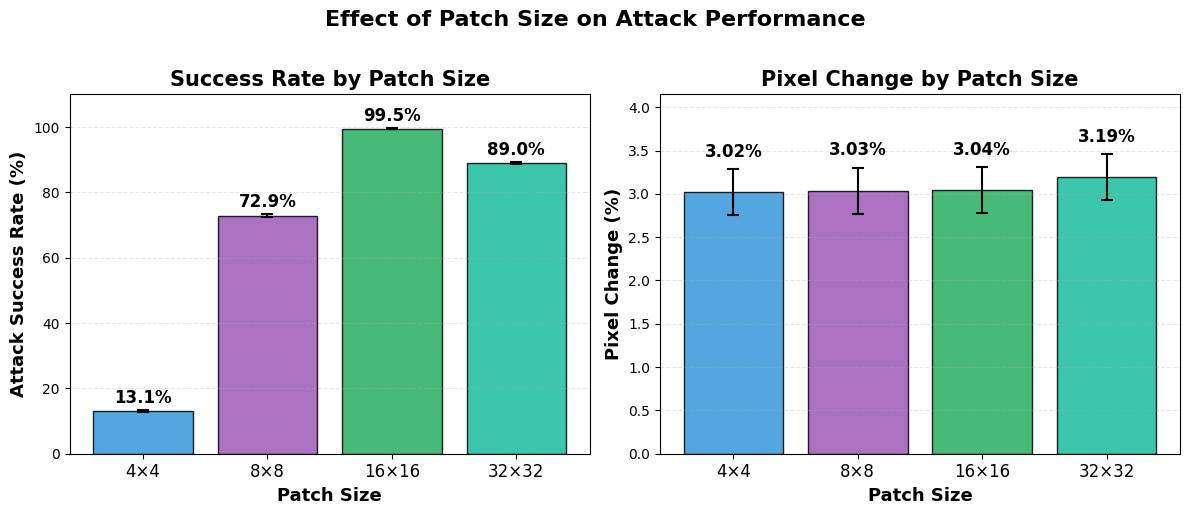


Patch size comparison saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\patch_size_comparison.png


In [16]:
# Patch Size Analysis: Compare 4x4, 8x8, 16x16, 32x32
print("\n" + "="*80)
print("PATCH SIZE ANALYSIS")
print("="*80)

patch_sizes = ['Patch_4', 'Patch_8', 'Patch_16_rejuv', 'Patch_32']
patch_labels = ['4×4', '8×8', '16×16', '32×32']
patch_colors = ['#3498db', '#9b59b6', '#27ae60', '#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Get data for patch sizes
sr_values = []
sr_errors = []
px_values = []
px_errors = []

for patch in patch_sizes:
    row = ablation_table[ablation_table['Method'] == patch]
    if len(row) > 0:
        row = row.iloc[0]
        sr_values.append(row['Success_Rate'])
        sr_errors.append(row['Success_SE'] if not pd.isna(row['Success_SE']) else 0)
        px_values.append(row['Pixel%'] if not pd.isna(row['Pixel%']) else 0)
        px_errors.append(row['Pixel_SE'] if not pd.isna(row['Pixel_SE']) else 0)
    else:
        sr_values.append(0)
        sr_errors.append(0)
        px_values.append(0)
        px_errors.append(0)

x = np.arange(len(patch_labels))

# Success Rate by Patch Size
ax = axes[0]
bars = ax.bar(x, sr_values, color=patch_colors, alpha=0.85, edgecolor='black',
              yerr=sr_errors, capsize=4, error_kw={'elinewidth': 1.5, 'capthick': 1.5})

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + sr_errors[i] + 1,
           f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Patch Size', fontweight='bold', fontsize=13)
ax.set_ylabel('Attack Success Rate (%)', fontweight='bold', fontsize=13)
ax.set_title('Success Rate by Patch Size', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(patch_labels, fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Pixel Change by Patch Size
ax = axes[1]
bars = ax.bar(x, px_values, color=patch_colors, alpha=0.85, edgecolor='black',
              yerr=px_errors, capsize=4, error_kw={'elinewidth': 1.5, 'capthick': 1.5})

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + px_errors[i] + 0.1,
           f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Patch Size', fontweight='bold', fontsize=13)
ax.set_ylabel('Pixel Change (%)', fontweight='bold', fontsize=13)
ax.set_title('Pixel Change by Patch Size', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(patch_labels, fontsize=12)
ax.set_ylim(0, max(px_values) * 1.3 if max(px_values) > 0 else 10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Effect of Patch Size on Attack Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'patch_size_comparison.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_PATH, 'patch_size_comparison.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"\nPatch size comparison saved to: {os.path.join(FIGURES_PATH, 'patch_size_comparison.png')}")


REJUVENATION & SIMULATION ABLATION (16×16 Patch)


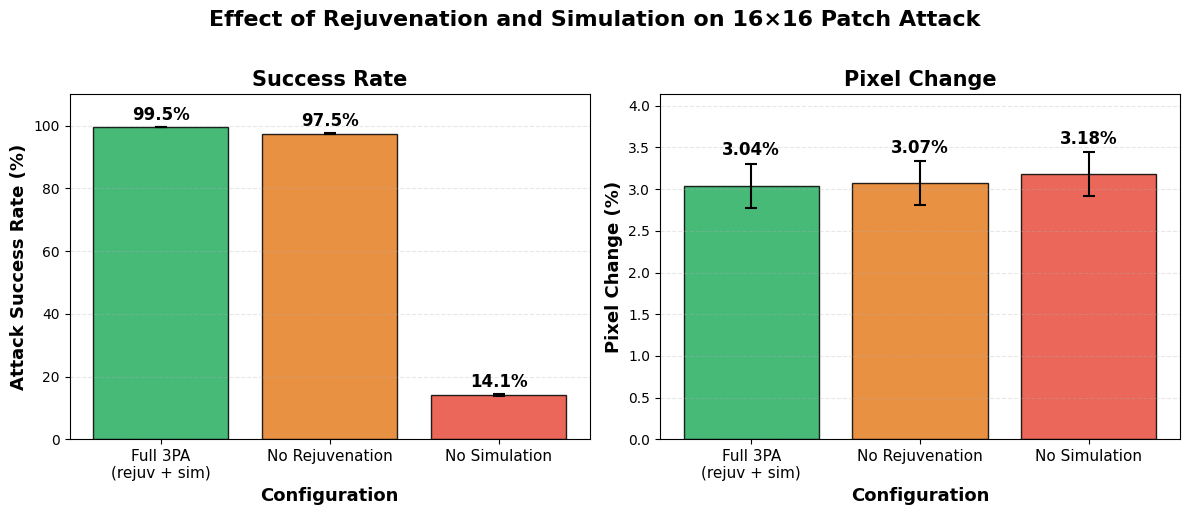


Rejuv/Sim ablation saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\rejuv_sim_ablation.png


In [17]:
# Rejuvenation and Simulation Ablation (16x16 patch)
print("\n" + "="*80)
print("REJUVENATION & SIMULATION ABLATION (16×16 Patch)")
print("="*80)

ablation_methods = ['Patch_16_rejuv', 'Patch_16_no_rejuv_orig', 'Patch_16_no_sim']
ablation_labels = ['Full 3PA\n(rejuv + sim)', 'No Rejuvenation', 'No Simulation']
ablation_colors = ['#27ae60', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Get data
sr_values = []
sr_errors = []
px_values = []
px_errors = []

for method in ablation_methods:
    row = ablation_table[ablation_table['Method'] == method]
    if len(row) > 0:
        row = row.iloc[0]
        sr_values.append(row['Success_Rate'])
        sr_errors.append(row['Success_SE'] if not pd.isna(row['Success_SE']) else 0)
        px_values.append(row['Pixel%'] if not pd.isna(row['Pixel%']) else 0)
        px_errors.append(row['Pixel_SE'] if not pd.isna(row['Pixel_SE']) else 0)
    else:
        sr_values.append(0)
        sr_errors.append(0)
        px_values.append(0)
        px_errors.append(0)

x = np.arange(len(ablation_labels))

# Success Rate
ax = axes[0]
bars = ax.bar(x, sr_values, color=ablation_colors, alpha=0.85, edgecolor='black',
              yerr=sr_errors, capsize=4, error_kw={'elinewidth': 1.5, 'capthick': 1.5})

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + sr_errors[i] + 1,
           f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Configuration', fontweight='bold', fontsize=13)
ax.set_ylabel('Attack Success Rate (%)', fontweight='bold', fontsize=13)
ax.set_title('Success Rate', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ablation_labels, fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Pixel Change
ax = axes[1]
bars = ax.bar(x, px_values, color=ablation_colors, alpha=0.85, edgecolor='black',
              yerr=px_errors, capsize=4, error_kw={'elinewidth': 1.5, 'capthick': 1.5})

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + px_errors[i] + 0.05,
           f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Configuration', fontweight='bold', fontsize=13)
ax.set_ylabel('Pixel Change (%)', fontweight='bold', fontsize=13)
ax.set_title('Pixel Change', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ablation_labels, fontsize=11)
ax.set_ylim(0, max(px_values) * 1.3 if max(px_values) > 0 else 5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Effect of Rejuvenation and Simulation on 16×16 Patch Attack', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'rejuv_sim_ablation.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_PATH, 'rejuv_sim_ablation.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"\nRejuv/Sim ablation saved to: {os.path.join(FIGURES_PATH, 'rejuv_sim_ablation.png')}")


SUCCESS RATE VS VIEWING ANGLE


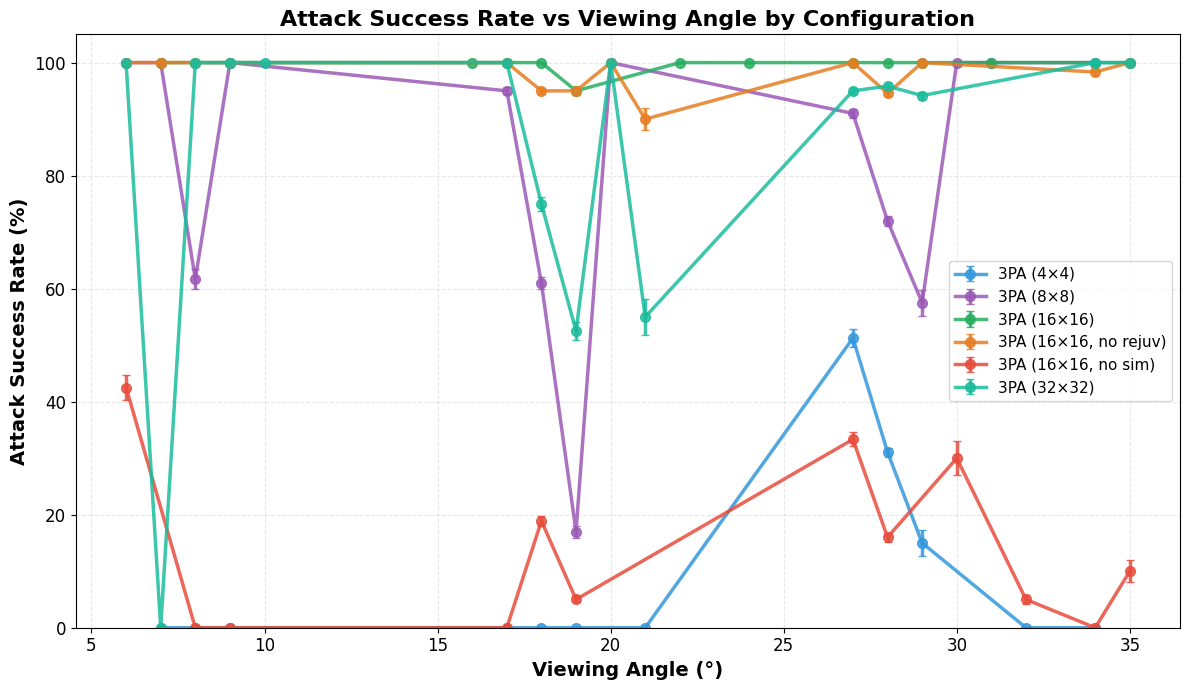


Angle analysis saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\success_vs_angle.png


In [18]:
# Success Rate vs Viewing Angle Analysis
print("\n" + "="*80)
print("SUCCESS RATE VS VIEWING ANGLE")
print("="*80)

if 'angle' in predictions_df.columns:
    # Group by approach and angle, calculate success rate
    angle_data = []
    
    for approach in DISPLAY_ORDER:
        approach_df = predictions_df[predictions_df['approach'] == approach]
        if len(approach_df) == 0:
            continue
        
        approach_df = approach_df.copy()
        approach_df['angle_rounded'] = approach_df['angle'].round(0)
        
        for angle_val in sorted(approach_df['angle_rounded'].unique()):
            angle_df = approach_df[approach_df['angle_rounded'] == angle_val]
            
            success_rate = angle_df['success'].mean() * 100
            n_samples = len(angle_df)
            se = (angle_df['success'].std(ddof=1) / np.sqrt(n_samples)) * 100 if n_samples > 1 else 0
            
            angle_data.append({
                'Approach': approach,
                'Angle': angle_val,
                'Success_Rate': success_rate,
                'SE': se,
                'N_Samples': n_samples
            })
    
    angle_df = pd.DataFrame(angle_data)
    
    # Plot: Success rate vs angle for 3PA configurations only
    fig, ax = plt.subplots(figsize=(12, 7))
    
    plot_approaches = [a for a in DISPLAY_ORDER if a.startswith('Patch_')]
    
    for approach in plot_approaches:
        approach_data = angle_df[angle_df['Approach'] == approach].sort_values('Angle')
        if len(approach_data) == 0:
            continue
        
        config = ABLATION_CONFIGS[approach]
        ax.errorbar(approach_data['Angle'], approach_data['Success_Rate'],
                   yerr=approach_data['SE'],
                   label=config['display_name'], color=config['color'],
                   marker='o', markersize=7, linewidth=2.5,
                   capsize=3, capthick=1, alpha=0.85)
    
    ax.set_xlabel('Viewing Angle (°)', fontweight='bold', fontsize=14)
    ax.set_ylabel('Attack Success Rate (%)', fontweight='bold', fontsize=14)
    ax.set_title('Attack Success Rate vs Viewing Angle by Configuration', 
                 fontsize=16, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, 'success_vs_angle.png'), dpi=150, bbox_inches='tight')
    plt.savefig(os.path.join(FIGURES_PATH, 'success_vs_angle.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    
    print(f"\nAngle analysis saved to: {os.path.join(FIGURES_PATH, 'success_vs_angle.png')}")
else:
    print("No angle data available in predictions")

In [19]:
# Generate LaTeX table for paper
print("\n" + "="*80)
print("LATEX TABLE (Copy for paper)")
print("="*80)

def generate_ablation_latex(table):
    """Generate LaTeX table for ablation study"""
    
    # Find winners among 3PA methods
    patch_table = table[table['Method'].str.startswith('Patch_')]
    
    best_success_method = patch_table.loc[patch_table['Success_Rate'].idxmax(), 'Method'] if len(patch_table) > 0 else None
    best_pixel_method = patch_table.loc[patch_table['Pixel%'].idxmin(), 'Method'] if len(patch_table) > 0 else None
    
    latex_code = r"""\begin{table}[htbp]
\centering
\caption{Ablation Study: Effect of patch size, rejuvenation, and simulation on 3PA attack performance. 
\textbf{Bold} indicates best result among 3PA configurations. Classifier: MobileNet.}
\label{tab:ablation}
\begin{tabular}{lcc}
\toprule
\textbf{Configuration} & \textbf{Success Rate (\%)} $\uparrow$ & \textbf{Pixel Change (\%)} $\downarrow$ \\
\midrule
"""
    
    for _, row in table.iterrows():
        method = row['Method']
        display_name = row['Display_Name']
        
        # Format success rate
        sr = row['Success_Rate']
        sr_se = row['Success_SE']
        if pd.isna(sr):
            sr_str = '--'
        elif pd.isna(sr_se) or sr_se == 0:
            sr_str = f'{sr:.1f}'
        else:
            sr_str = f'{sr:.1f}$\\pm${sr_se:.1f}'
        
        if method == best_success_method:
            sr_str = f'\\textbf{{{sr_str}}}'
        
        # Format pixel change
        px = row['Pixel%']
        px_se = row['Pixel_SE']
        if pd.isna(px):
            px_str = '--'
        elif pd.isna(px_se) or px_se == 0:
            px_str = f'{px:.2f}'
        else:
            px_str = f'{px:.2f}$\\pm${px_se:.2f}'
        
        if method == best_pixel_method:
            px_str = f'\\textbf{{{px_str}}}'
        
        latex_code += f"{display_name} & {sr_str} & {px_str} \\\\\n"
        
        # Add midrule after baselines
        if method == 'Baseline_Noise':
            latex_code += "\\midrule\n"
    
    latex_code += r"""\bottomrule
\end{tabular}
\end{table}"""
    
    return latex_code

latex_table = generate_ablation_latex(ablation_table)
print(latex_table)


LATEX TABLE (Copy for paper)
\begin{table}[htbp]
\centering
\caption{Ablation Study: Effect of patch size, rejuvenation, and simulation on 3PA attack performance. 
\textbf{Bold} indicates best result among 3PA configurations. Classifier: MobileNet.}
\label{tab:ablation}
\begin{tabular}{lcc}
\toprule
\textbf{Configuration} & \textbf{Success Rate (\%)} $\uparrow$ & \textbf{Pixel Change (\%)} $\downarrow$ \\
\midrule
No Attack & 0.0 & 0.00 \\
Random Noise & 41.6$\pm$0.6 & 56.28$\pm$1.08 \\
\midrule
3PA (4×4) & 13.1$\pm$0.3 & \textbf{3.02$\pm$0.27} \\
3PA (8×8) & 72.9$\pm$0.4 & 3.03$\pm$0.27 \\
3PA (16×16) & \textbf{99.5$\pm$0.1} & 3.04$\pm$0.26 \\
3PA (16×16, no rejuv) & 97.5$\pm$0.1 & 3.07$\pm$0.26 \\
3PA (16×16, no sim) & 14.1$\pm$0.3 & 3.18$\pm$0.27 \\
3PA (32×32) & 89.0$\pm$0.3 & 3.19$\pm$0.27 \\
\bottomrule
\end{tabular}
\end{table}


In [20]:
# Summary statistics and key findings
print("\n" + "="*80)
print("SUMMARY & KEY FINDINGS")
print("="*80)

# Get baseline references
baseline_row = ablation_table[ablation_table['Method'] == 'Baseline']
baseline_noise_row = ablation_table[ablation_table['Method'] == 'Baseline_Noise']

print("\n1. BASELINE COMPARISONS:")
if len(baseline_row) > 0:
    row = baseline_row.iloc[0]
    print(f"   - No Attack: Success Rate = {row['Success_Rate']:.1f}%")
if len(baseline_noise_row) > 0:
    row = baseline_noise_row.iloc[0]
    print(f"   - Random Noise: Success Rate = {row['Success_Rate']:.1f}%, Pixel Change = {row['Pixel%']:.1f}%")

print("\n2. PATCH SIZE COMPARISON:")
for patch, label in [('Patch_4', '4×4'), ('Patch_8', '8×8'), ('Patch_16_rejuv', '16×16'), ('Patch_32', '32×32')]:
    row = ablation_table[ablation_table['Method'] == patch]
    if len(row) > 0:
        row = row.iloc[0]
        print(f"   - {label}: Success = {row['Success_Rate']:.1f}%, Pixel = {row['Pixel%']:.2f}%")

print("\n3. COMPONENT ABLATION (16×16 patch):")
for config, label in [('Patch_16_rejuv', 'Full (rejuv + sim)'), ('Patch_16_no_rejuv_orig', 'No Rejuvenation'), ('Patch_16_no_sim', 'No Simulation')]:
    row = ablation_table[ablation_table['Method'] == config]
    if len(row) > 0:
        row = row.iloc[0]
        print(f"   - {label}: Success = {row['Success_Rate']:.1f}%")

# Find best configuration
patch_methods = ablation_table[ablation_table['Method'].str.startswith('Patch_')]
if len(patch_methods) > 0:
    best_success = patch_methods.loc[patch_methods['Success_Rate'].idxmax()]
    best_pixel = patch_methods.loc[patch_methods['Pixel%'].idxmin()]
    
    print(f"\n4. BEST CONFIGURATIONS:")
    print(f"   - Highest Success Rate: {best_success['Display_Name']} ({best_success['Success_Rate']:.1f}%)")
    print(f"   - Lowest Pixel Change: {best_pixel['Display_Name']} ({best_pixel['Pixel%']:.2f}%)")

print("\n" + "="*80)


SUMMARY & KEY FINDINGS

1. BASELINE COMPARISONS:
   - No Attack: Success Rate = 0.0%
   - Random Noise: Success Rate = 41.6%, Pixel Change = 56.3%

2. PATCH SIZE COMPARISON:
   - 4×4: Success = 13.1%, Pixel = 3.02%
   - 8×8: Success = 72.9%, Pixel = 3.03%
   - 16×16: Success = 99.5%, Pixel = 3.04%
   - 32×32: Success = 89.0%, Pixel = 3.19%

3. COMPONENT ABLATION (16×16 patch):
   - Full (rejuv + sim): Success = 99.5%
   - No Rejuvenation: Success = 97.5%
   - No Simulation: Success = 14.1%

4. BEST CONFIGURATIONS:
   - Highest Success Rate: 3PA (16×16) (99.5%)
   - Lowest Pixel Change: 3PA (4×4) (3.02%)



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from torchvision.models import Inception_V3_Weights

# Load ImageNet class labels from torchvision model metadata
imagenet_weights = Inception_V3_Weights.IMAGENET1K_V1
IMAGENET_CATEGORIES = imagenet_weights.meta['categories']

def get_class_names(indices):
    """Get class names from ImageNet indices using torchvision metadata"""
    return [IMAGENET_CATEGORIES[i] for i in indices]

# Experiment path
EXPERIMENT_PATH = r"C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33"
DATA_PATH = os.path.join(EXPERIMENT_PATH, 'data')

# Model definitions
V1_MODELS = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit']  # Seen (trained on)
V2_MODELS = ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin']  # Unseen
DINO_MODEL = 'dino_standalone'

# Ablation configurations - different 3PA parameter variations
# Note: 'Baseline' is no attack, 'Baseline_Noise' is random noise
ABLATION_CONFIGS = {
    'Baseline': {
        'display_name': 'No Attack',
        'color': '#bdc3c7',
        'description': 'No projection (original scene)'
    },
    'Baseline_Noise': {
        'display_name': 'Random Noise',
        'color': '#95a5a6',
        'description': 'Random noise projection'
    },
    'Patch_4': {
        'display_name': '3PA (4×4)',
        'color': '#3498db',
        'description': '4×4 patch grid'
    },
    'Patch_8': {
        'display_name': '3PA (8×8)',
        'color': '#9b59b6',
        'description': '8×8 patch grid'
    },
    'Patch_16_rejuv': {
        'display_name': '3PA (16×16)',
        'color': '#27ae60',
        'description': '16×16 patch grid with rejuvenation (default)'
    },
    'Patch_16_no_rejuv_orig': {
        'display_name': '3PA (16×16, no rejuv)',
        'color': '#e67e22',
        'description': '16×16 patch grid without rejuvenation'
    },
    'Patch_16_no_sim': {
        'display_name': '3PA (16×16, no sim)',
        'color': '#e74c3c',
        'description': '16×16 patch grid without simulation'
    },
    'Patch_32': {
        'display_name': '3PA (32×32)',
        'color': '#1abc9c',
        'description': '32×32 patch grid'
    }
}

# Order for display (logical grouping)
DISPLAY_ORDER = ['Baseline', 'Baseline_Noise', 'Patch_4', 'Patch_8', 'Patch_16_rejuv', 
                 'Patch_16_no_rejuv_orig', 'Patch_16_no_sim', 'Patch_32']

# Forbidden classes for this scene (mailbag)
FORBIDDEN_INDICES = [549]  # mailbag
FORBIDDEN_CLASSES = get_class_names(FORBIDDEN_INDICES)

print(f"Experiment path: {EXPERIMENT_PATH}")
print(f"Ablation configurations: {list(ABLATION_CONFIGS.keys())}")
print(f"V1 Models (Seen): {V1_MODELS}")
print(f"V2 Models (Unseen): {V2_MODELS}")
print(f"Forbidden classes: {FORBIDDEN_CLASSES}")

Experiment path: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33
Ablation configurations: ['Baseline', 'Baseline_Noise', 'Patch_4', 'Patch_8', 'Patch_16_rejuv', 'Patch_16_no_rejuv_orig', 'Patch_16_no_sim', 'Patch_32']
V1 Models (Seen): ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit']
V2 Models (Unseen): ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin']
Forbidden classes: ['envelope']


In [22]:
def load_predictions_data():
    """Load raw predictions data"""
    pred_path = os.path.join(DATA_PATH, 'raw_predictions.csv')
    
    if not os.path.exists(pred_path):
        print(f"Error: {pred_path} not found")
        return None
    
    df = pd.read_csv(pred_path)
    print(f"Loaded {len(df)} predictions")
    print(f"Unique approaches: {df['approach'].unique()}")
    print(f"Unique models: {df['model'].unique()}")
    
    # The 'success' column already exists in the data (True if attack succeeded)
    # For ablation, success means the model did NOT predict the forbidden class
    # Verify by checking predicted classes
    print(f"\nSample predicted classes: {df['predicted_class'].unique()[:10]}")
    
    return df

def load_pixel_change_data():
    """Load pixel change analysis data"""
    pixel_path = os.path.join(DATA_PATH, 'pixel_change_analysis.csv')
    
    if not os.path.exists(pixel_path):
        print(f"Warning: {pixel_path} not found")
        return None, None
    
    df = pd.read_csv(pixel_path)
    print(f"Loaded {len(df)} pixel change entries")
    
    # Calculate mean and SE per approach
    pixel_data = {}
    pixel_se_data = {}
    
    for approach in df['approach'].unique():
        approach_df = df[df['approach'] == approach]
        pixel_data[approach] = approach_df['pixel_change_pct'].mean()
        n = len(approach_df)
        if n > 1:
            pixel_se_data[approach] = approach_df['pixel_change_pct'].std(ddof=1) / np.sqrt(n)
        else:
            pixel_se_data[approach] = 0.0
    
    # Baseline has 0% pixel change
    pixel_data['Baseline'] = 0.0
    pixel_se_data['Baseline'] = 0.0
    
    return pixel_data, pixel_se_data

# Load data
print("Loading experiment data...")
predictions_df = load_predictions_data()
pixel_data, pixel_se_data = load_pixel_change_data()

print(f"\nPixel change data:")
for approach, val in sorted(pixel_data.items(), key=lambda x: x[1]):
    se = pixel_se_data.get(approach, 0)
    print(f"  {approach}: {val:.2f}% ± {se:.2f}%")

Loading experiment data...
Loaded 84000 predictions
Unique approaches: ['Baseline' 'Baseline_Noise' 'Patch_16_rejuv' 'Patch_16_no_rejuv_orig'
 'Patch_32' 'Patch_8' 'Patch_4' 'Patch_16_no_sim']
Unique models: ['v1_inception' 'v1_resnet' 'v1_vgg' 'v1_vit' 'v1_dino' 'v1_combined'
 'v2_convnext' 'v2_efficientnet' 'v2_mobilenet' 'v2_swin' 'v2_combined'
 'dino_standalone']

Sample predicted classes: ['mailbag' 'backpack' 'switch' 'Polaroid camera' 'printer'
 'soap dispenser' 'iron' 'loudspeaker' 'carton' 'purse']
Loaded 325 pixel change entries

Pixel change data:
  Baseline: 0.00% ± 0.00%
  Patch_4: 3.02% ± 0.27%
  Patch_8: 3.03% ± 0.27%
  Patch_16_rejuv: 3.04% ± 0.26%
  Patch_16_no_rejuv_orig: 3.07% ± 0.26%
  Patch_16_no_sim: 3.18% ± 0.27%
  Patch_32: 3.19% ± 0.27%
  Baseline_Noise: 56.28% ± 1.08%


In [23]:
def calc_se(data):
    """Calculate standard error of the mean"""
    if len(data) == 0:
        return np.nan
    return np.std(data, ddof=1) / np.sqrt(len(data)) * 100  # Convert to percentage

def build_ablation_table(df, approaches, v1_models, v2_models, dino_model, pixel_data=None, pixel_se_data=None):
    """Build ablation table with success rates and standard errors"""
    results = []
    
    for approach in approaches:
        if approach not in df['approach'].unique():
            continue
        
        config = ABLATION_CONFIGS.get(approach, {})
        row = {
            'Method': approach,
            'Display_Name': config.get('display_name', approach)
        }
        
        # Pixel change percentage
        if pixel_data and approach in pixel_data:
            row['Pixel%'] = pixel_data[approach]
            row['Pixel_SE'] = pixel_se_data.get(approach, 0) if pixel_se_data else 0
        else:
            row['Pixel%'] = np.nan
            row['Pixel_SE'] = np.nan
        
        # V1 individual models (Seen)
        v1_rates = []
        for model in v1_models:
            model_data = df[(df['approach'] == approach) & (df['model'] == model)]
            rate = model_data['success'].mean() * 100 if len(model_data) > 0 else np.nan
            se = calc_se(model_data['success']) if len(model_data) > 0 else np.nan
            row[model.replace('v1_', 'Seen-')] = rate
            row[model.replace('v1_', 'Seen-') + '_SE'] = se
            if not np.isnan(rate):
                v1_rates.append(rate)
        row['Seen-Avg'] = np.mean(v1_rates) if v1_rates else np.nan
        row['Seen-Avg_SE'] = np.std(v1_rates) / np.sqrt(len(v1_rates)) if len(v1_rates) > 0 else np.nan
        
        # DINO
        dino_data = df[(df['approach'] == approach) & (df['model'] == dino_model)]
        row['DINO'] = dino_data['success'].mean() * 100 if len(dino_data) > 0 else np.nan
        row['DINO_SE'] = calc_se(dino_data['success']) if len(dino_data) > 0 else np.nan
        
        # V2 individual models (Unseen)
        v2_rates = []
        for model in v2_models:
            model_data = df[(df['approach'] == approach) & (df['model'] == model)]
            rate = model_data['success'].mean() * 100 if len(model_data) > 0 else np.nan
            se = calc_se(model_data['success']) if len(model_data) > 0 else np.nan
            row[model.replace('v2_', 'Unseen-')] = rate
            row[model.replace('v2_', 'Unseen-') + '_SE'] = se
            if not np.isnan(rate):
                v2_rates.append(rate)
        row['Unseen-Avg'] = np.mean(v2_rates) if v2_rates else np.nan
        row['Unseen-Avg_SE'] = np.std(v2_rates) / np.sqrt(len(v2_rates)) if len(v2_rates) > 0 else np.nan
        
        # Overall average (excluding baselines for comparison)
        all_rates = v1_rates + [row['DINO']] + v2_rates if not np.isnan(row['DINO']) else v1_rates + v2_rates
        all_rates = [r for r in all_rates if not np.isnan(r)]
        row['Overall-Avg'] = np.mean(all_rates) if all_rates else np.nan
        
        results.append(row)
    
    table = pd.DataFrame(results)
    return table

# Build ablation table
ablation_table = build_ablation_table(
    predictions_df, DISPLAY_ORDER, V1_MODELS, V2_MODELS, DINO_MODEL, 
    pixel_data, pixel_se_data
)

# Display summary
print("\n" + "="*100)
print("ABLATION STUDY RESULTS")
print("="*100)

# Display columns without SE for cleaner view
display_cols = ['Display_Name', 'Pixel%', 'Seen-Avg', 'DINO', 'Unseen-Avg', 'Overall-Avg']
print(ablation_table[display_cols].to_string(index=False))


ABLATION STUDY RESULTS
         Display_Name    Pixel%  Seen-Avg  DINO  Unseen-Avg  Overall-Avg
            No Attack  0.000000       0.0   0.0         0.0          0.0
         Random Noise 56.283494      41.6  41.6        41.6         41.6
            3PA (4×4)  3.017660      13.1  13.1        13.1         13.1
            3PA (8×8)  3.034951      72.9  72.9        72.9         72.9
          3PA (16×16)  3.041772      99.5  99.5        99.5         99.5
3PA (16×16, no rejuv)  3.069132      97.5  97.5        97.5         97.5
  3PA (16×16, no sim)  3.182573      14.1  14.1        14.1         14.1
          3PA (32×32)  3.191436      89.0  89.0        89.0         89.0


In [24]:
def format_with_se(table):
    """Format table values with ± SE for display"""
    display_table = pd.DataFrame()
    display_table['Configuration'] = table['Display_Name']
    
    # Value columns and their SE counterparts
    value_cols = ['Pixel%', 'Seen-Avg', 'DINO', 'Unseen-Avg', 'Overall-Avg']
    se_mapping = {'Pixel%': 'Pixel_SE', 'Seen-Avg': 'Seen-Avg_SE', 'DINO': 'DINO_SE', 
                  'Unseen-Avg': 'Unseen-Avg_SE'}
    
    for col in value_cols:
        if col in table.columns:
            se_col = se_mapping.get(col)
            formatted = []
            for _, row in table.iterrows():
                val = row[col]
                se = row.get(se_col, np.nan) if se_col and se_col in row else np.nan
                if pd.isna(val):
                    formatted.append('N/A')
                elif pd.isna(se) or se == 0:
                    formatted.append(f'{val:.1f}')
                else:
                    formatted.append(f'{val:.1f}±{se:.1f}')
            display_table[col] = formatted
    
    return display_table

# Display formatted table with SE
print("\n" + "="*100)
print("ABLATION RESULTS (with Standard Errors)")
print("="*100)

formatted_table = format_with_se(ablation_table)
print(formatted_table.to_string(index=False))


ABLATION RESULTS (with Standard Errors)
        Configuration   Pixel% Seen-Avg     DINO Unseen-Avg Overall-Avg
            No Attack      0.0      0.0      0.0        0.0         0.0
         Random Noise 56.3±1.1     41.6 41.6±2.2       41.6        41.6
            3PA (4×4)  3.0±0.3     13.1 13.1±1.1       13.1        13.1
            3PA (8×8)  3.0±0.3     72.9 72.9±1.4       72.9        72.9
          3PA (16×16)  3.0±0.3     99.5 99.5±0.2       99.5        99.5
3PA (16×16, no rejuv)  3.1±0.3     97.5 97.5±0.5       97.5        97.5
  3PA (16×16, no sim)  3.2±0.3     14.1 14.1±1.1       14.1        14.1
          3PA (32×32)  3.2±0.3     89.0 89.0±1.0       89.0        89.0


Figures will be saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures


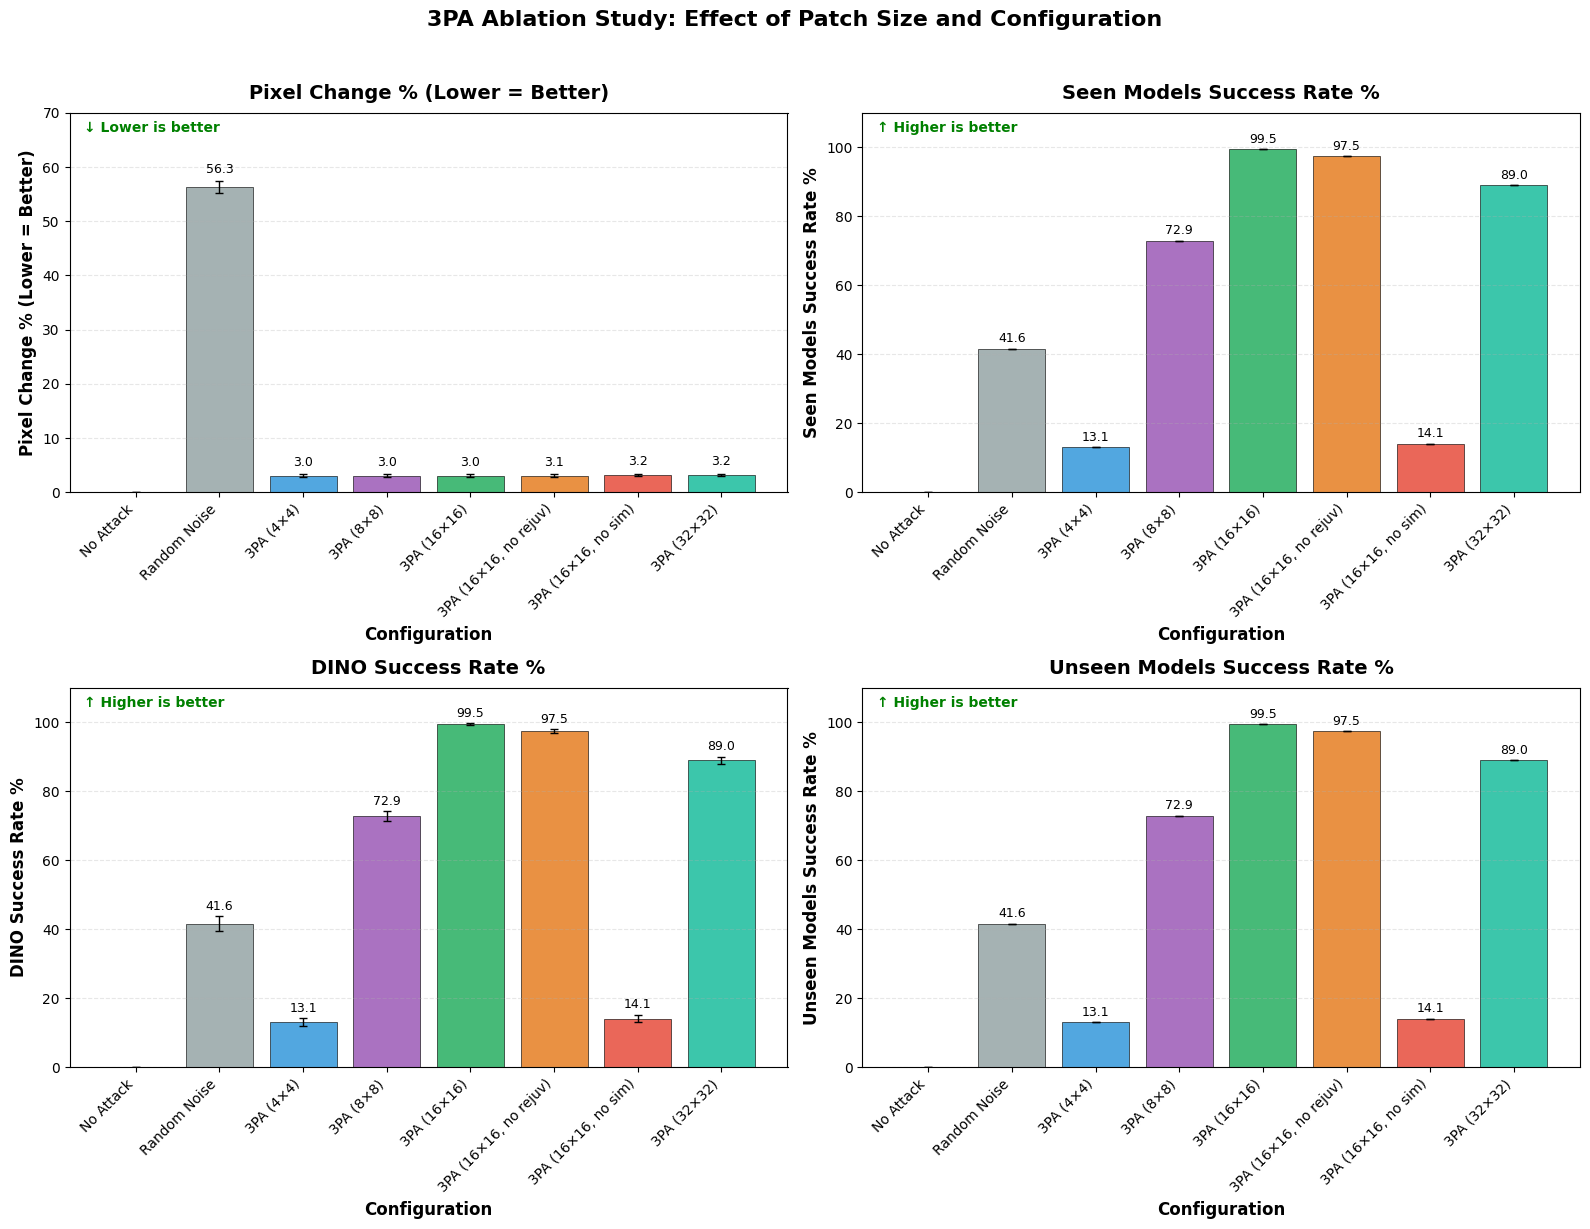


Chart saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\ablation_comparison.png


In [25]:
# Create output directory for figures
FIGURES_PATH = os.path.join(EXPERIMENT_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)
print(f"Figures will be saved to: {FIGURES_PATH}")

# Bar chart: All ablation configurations comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['Pixel%', 'Seen-Avg', 'DINO', 'Unseen-Avg']
se_cols = ['Pixel_SE', 'Seen-Avg_SE', 'DINO_SE', 'Unseen-Avg_SE']
metric_titles = ['Pixel Change % (Lower = Better)', 'Seen Models Success Rate %', 
                 'DINO Success Rate %', 'Unseen Models Success Rate %']

for idx, (metric, se_col, title) in enumerate(zip(metrics, se_cols, metric_titles)):
    ax = axes[idx]
    
    # Get data for each configuration
    configs = []
    values = []
    errors = []
    colors = []
    
    for approach in DISPLAY_ORDER:
        row = ablation_table[ablation_table['Method'] == approach]
        if len(row) == 0:
            continue
        
        val = row[metric].values[0]
        se = row[se_col].values[0] if se_col in row.columns else 0
        
        configs.append(ABLATION_CONFIGS[approach]['display_name'])
        values.append(val if not pd.isna(val) else 0)
        errors.append(se if not pd.isna(se) else 0)
        colors.append(ABLATION_CONFIGS[approach]['color'])
    
    x = np.arange(len(configs))
    bars = ax.bar(x, values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5,
                  yerr=errors, capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, height + errors[i] + 1,
                   f'{height:.1f}', ha='center', va='bottom', fontsize=9, rotation=0)
    
    ax.set_xlabel('Configuration', fontweight='bold', fontsize=12)
    ax.set_ylabel(title, fontweight='bold', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    if metric == 'Pixel%':
        ax.set_ylim(0, 70)
        ax.annotate('↓ Lower is better', xy=(0.02, 0.95), xycoords='axes fraction',
                   fontsize=10, color='green', fontweight='bold')
    else:
        ax.set_ylim(0, 110)
        ax.annotate('↑ Higher is better', xy=(0.02, 0.95), xycoords='axes fraction',
                   fontsize=10, color='green', fontweight='bold')

plt.suptitle('3PA Ablation Study: Effect of Patch Size and Configuration', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'ablation_comparison.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_PATH, 'ablation_comparison.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"\nChart saved to: {os.path.join(FIGURES_PATH, 'ablation_comparison.png')}")


DETAILED HEATMAP: Success Rate by Configuration and Model


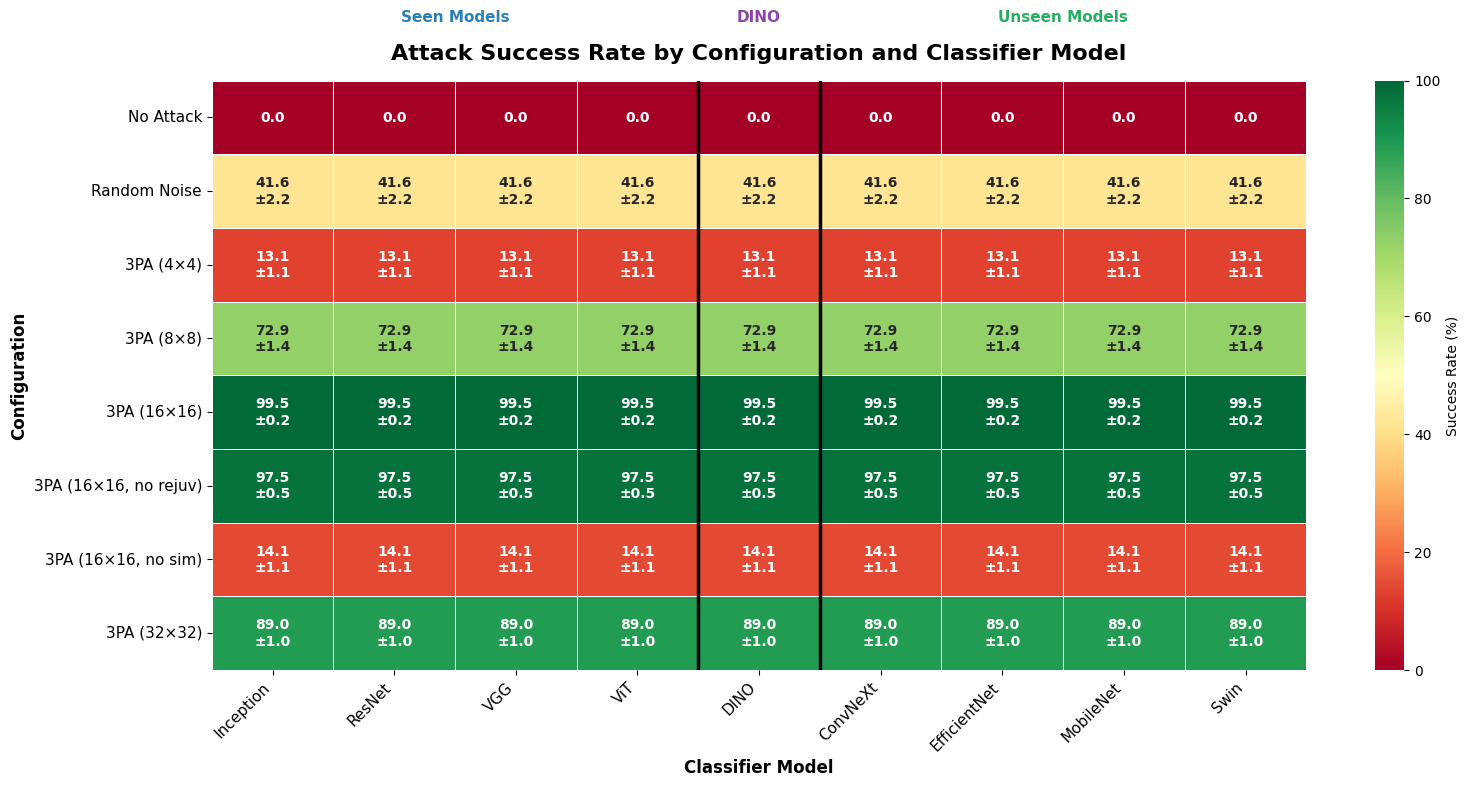


Heatmap saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\ablation_heatmap.png


In [26]:
# Heatmap: Success rates by configuration and model
print("\n" + "="*100)
print("DETAILED HEATMAP: Success Rate by Configuration and Model")
print("="*100)

# Build heatmap data
all_models = V1_MODELS + [DINO_MODEL] + V2_MODELS
model_display = {
    'v1_inception': 'Inception', 'v1_resnet': 'ResNet', 'v1_vgg': 'VGG', 'v1_vit': 'ViT',
    'dino_standalone': 'DINO',
    'v2_convnext': 'ConvNeXt', 'v2_efficientnet': 'EfficientNet', 
    'v2_mobilenet': 'MobileNet', 'v2_swin': 'Swin'
}

heatmap_data = []
annot_data = []

for approach in DISPLAY_ORDER:
    approach_df = predictions_df[predictions_df['approach'] == approach]
    if len(approach_df) == 0:
        continue
    
    row_vals = []
    row_annot = []
    
    for model in all_models:
        model_df = approach_df[approach_df['model'] == model]
        if len(model_df) > 0:
            rate = model_df['success'].mean() * 100
            se = calc_se(model_df['success'])
            row_vals.append(rate)
            if pd.isna(se) or se == 0:
                row_annot.append(f'{rate:.1f}')
            else:
                row_annot.append(f'{rate:.1f}\n±{se:.1f}')
        else:
            row_vals.append(np.nan)
            row_annot.append('')
    
    heatmap_data.append(row_vals)
    annot_data.append(row_annot)

# Create DataFrame for heatmap
config_labels = [ABLATION_CONFIGS[a]['display_name'] for a in DISPLAY_ORDER if a in predictions_df['approach'].unique()]
model_labels = [model_display[m] for m in all_models]

heatmap_df = pd.DataFrame(heatmap_data, index=config_labels, columns=model_labels)
annot_array = np.array(annot_data)

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(heatmap_df, annot=annot_array, fmt='', cmap='RdYlGn',
            center=50, vmin=0, vmax=100,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Success Rate (%)'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax)

ax.set_title('Attack Success Rate by Configuration and Classifier Model', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Classifier Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Configuration', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Add vertical lines to separate model groups
ax.axvline(x=4, color='black', linewidth=2.5)   # After V1 models
ax.axvline(x=5, color='black', linewidth=2.5)   # After DINO

# Add group labels
ax.text(2, -0.8, 'Seen Models', ha='center', fontsize=11, fontweight='bold', color='#2980b9')
ax.text(4.5, -0.8, 'DINO', ha='center', fontsize=11, fontweight='bold', color='#8e44ad')
ax.text(7, -0.8, 'Unseen Models', ha='center', fontsize=11, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'ablation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_PATH, 'ablation_heatmap.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"\nHeatmap saved to: {os.path.join(FIGURES_PATH, 'ablation_heatmap.png')}")


PATCH SIZE ANALYSIS


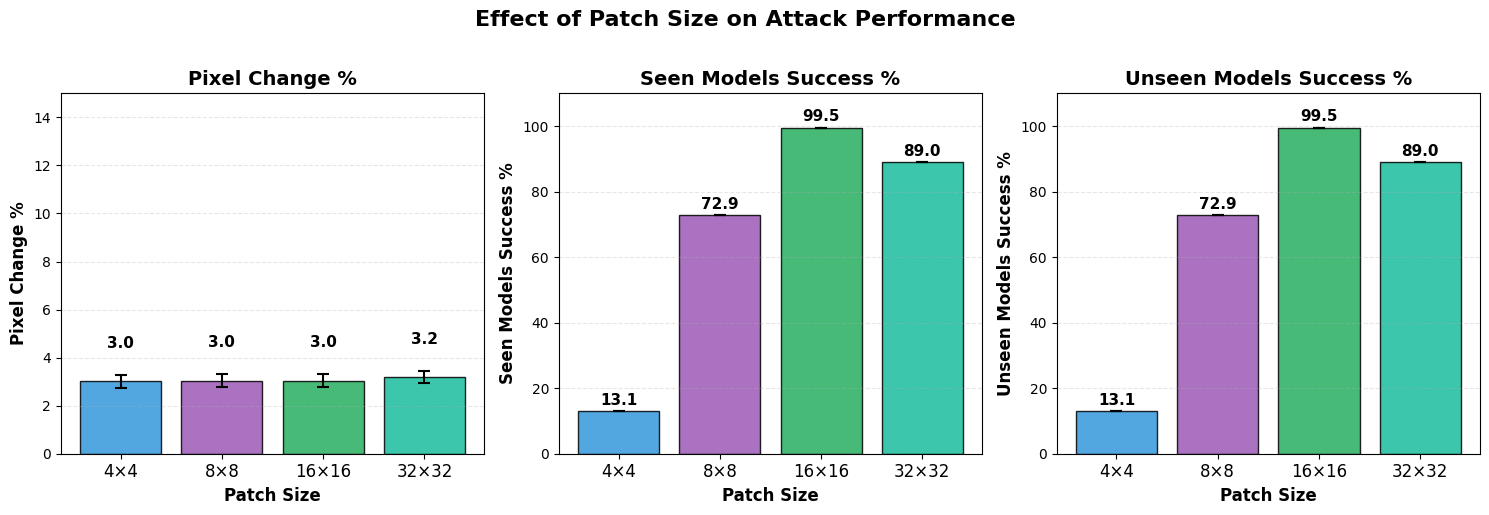


Patch size comparison saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\patch_size_comparison.png


In [27]:
# Patch Size Analysis: Compare 4x4, 8x8, 16x16, 32x32
print("\n" + "="*100)
print("PATCH SIZE ANALYSIS")
print("="*100)

patch_sizes = ['Patch_4', 'Patch_8', 'Patch_16_rejuv', 'Patch_32']
patch_labels = ['4×4', '8×8', '16×16', '32×32']
patch_colors = ['#3498db', '#9b59b6', '#27ae60', '#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Pixel%', 'Seen-Avg', 'Unseen-Avg']
se_cols = ['Pixel_SE', 'Seen-Avg_SE', 'Unseen-Avg_SE']
titles = ['Pixel Change %', 'Seen Models Success %', 'Unseen Models Success %']

for idx, (metric, se_col, title) in enumerate(zip(metrics, se_cols, titles)):
    ax = axes[idx]
    
    values = []
    errors = []
    
    for patch in patch_sizes:
        row = ablation_table[ablation_table['Method'] == patch]
        if len(row) > 0:
            val = row[metric].values[0]
            se = row[se_col].values[0] if se_col in row.columns else 0
            values.append(val if not pd.isna(val) else 0)
            errors.append(se if not pd.isna(se) else 0)
        else:
            values.append(0)
            errors.append(0)
    
    x = np.arange(len(patch_labels))
    bars = ax.bar(x, values, color=patch_colors, alpha=0.85, edgecolor='black',
                  yerr=errors, capsize=4, error_kw={'elinewidth': 1.5, 'capthick': 1.5})
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + errors[i] + 1,
               f'{height:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Patch Size', fontweight='bold', fontsize=12)
    ax.set_ylabel(title, fontweight='bold', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(patch_labels, fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    if metric == 'Pixel%':
        ax.set_ylim(0, 15)
    else:
        ax.set_ylim(0, 110)

plt.suptitle('Effect of Patch Size on Attack Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'patch_size_comparison.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_PATH, 'patch_size_comparison.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"\nPatch size comparison saved to: {os.path.join(FIGURES_PATH, 'patch_size_comparison.png')}")


REJUVENATION & SIMULATION ABLATION


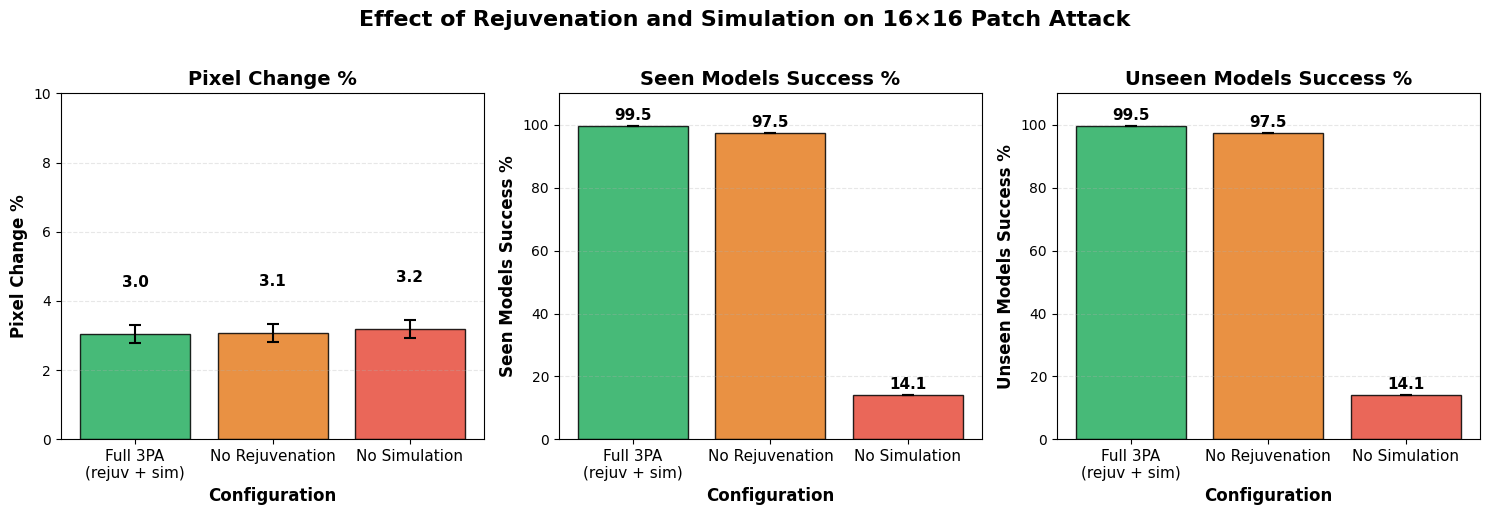


Rejuv/Sim ablation saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\rejuv_sim_ablation.png


In [28]:
# Rejuvenation and Simulation Ablation
print("\n" + "="*100)
print("REJUVENATION & SIMULATION ABLATION")
print("="*100)

# Compare: 16x16 with rejuv vs without rejuv vs without sim
ablation_configs = ['Patch_16_rejuv', 'Patch_16_no_rejuv_orig', 'Patch_16_no_sim']
ablation_labels = ['Full 3PA\n(rejuv + sim)', 'No Rejuvenation', 'No Simulation']
ablation_colors = ['#27ae60', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (metric, se_col, title) in enumerate(zip(metrics, se_cols, titles)):
    ax = axes[idx]
    
    values = []
    errors = []
    
    for config in ablation_configs:
        row = ablation_table[ablation_table['Method'] == config]
        if len(row) > 0:
            val = row[metric].values[0]
            se = row[se_col].values[0] if se_col in row.columns else 0
            values.append(val if not pd.isna(val) else 0)
            errors.append(se if not pd.isna(se) else 0)
        else:
            values.append(0)
            errors.append(0)
    
    x = np.arange(len(ablation_labels))
    bars = ax.bar(x, values, color=ablation_colors, alpha=0.85, edgecolor='black',
                  yerr=errors, capsize=4, error_kw={'elinewidth': 1.5, 'capthick': 1.5})
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + errors[i] + 1,
               f'{height:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Configuration', fontweight='bold', fontsize=12)
    ax.set_ylabel(title, fontweight='bold', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ablation_labels, fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    if metric == 'Pixel%':
        ax.set_ylim(0, 10)
    else:
        ax.set_ylim(0, 110)

plt.suptitle('Effect of Rejuvenation and Simulation on 16×16 Patch Attack', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'rejuv_sim_ablation.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_PATH, 'rejuv_sim_ablation.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"\nRejuv/Sim ablation saved to: {os.path.join(FIGURES_PATH, 'rejuv_sim_ablation.png')}")


SUCCESS RATE VS VIEWING ANGLE


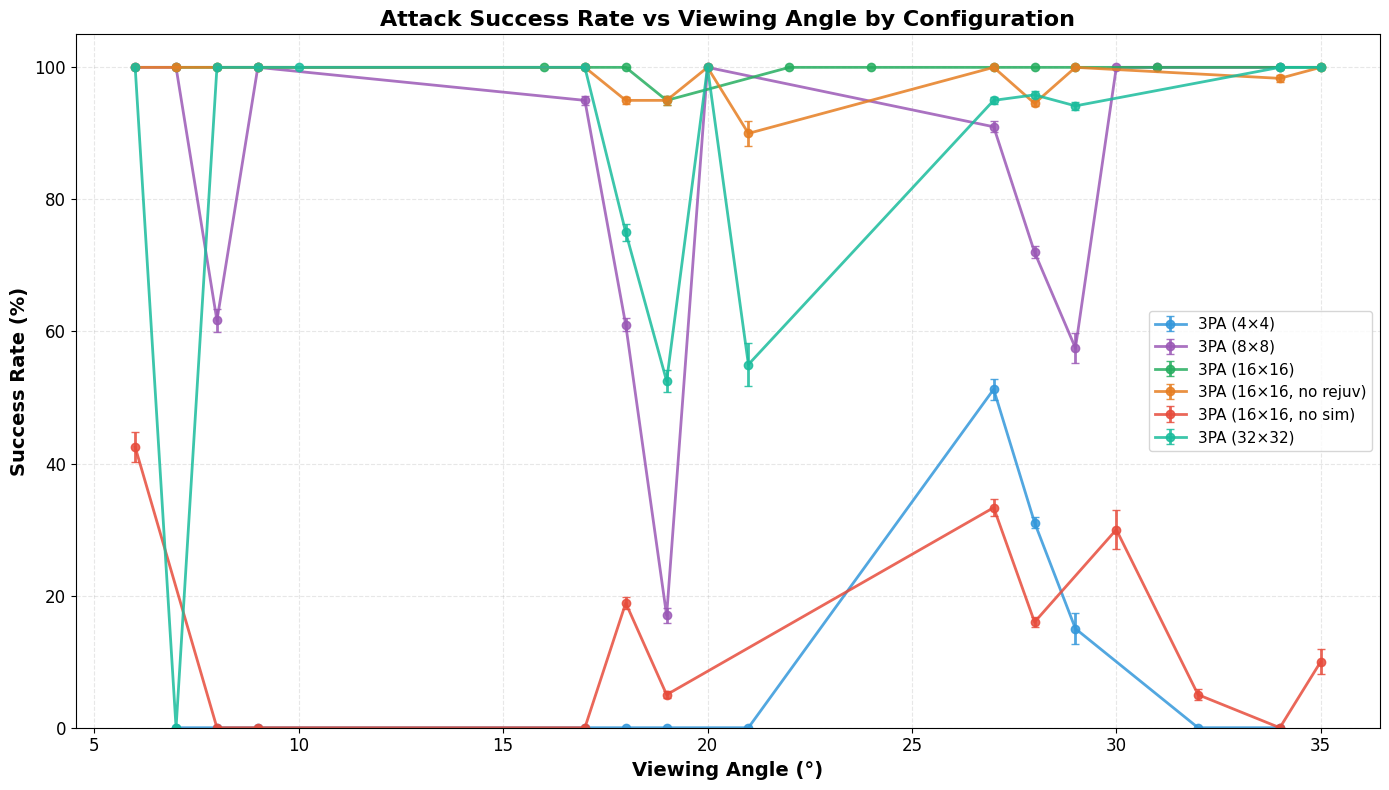


Angle analysis saved to: C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2026-01-18_17_34_33\figures\success_vs_angle.png


In [29]:
# Success Rate vs Angle Analysis
print("\n" + "="*100)
print("SUCCESS RATE VS VIEWING ANGLE")
print("="*100)

# Check if angle data is available
if 'angle' in predictions_df.columns:
    # Group by approach and angle, calculate success rate
    angle_data = []
    
    for approach in DISPLAY_ORDER:
        approach_df = predictions_df[predictions_df['approach'] == approach]
        if len(approach_df) == 0:
            continue
        
        approach_df = approach_df.copy()
        approach_df['angle_rounded'] = approach_df['angle'].round(0)
        
        for angle_val in approach_df['angle_rounded'].unique():
            angle_df = approach_df[approach_df['angle_rounded'] == angle_val]
            
            # Average across all models
            success_rate = angle_df['success'].mean() * 100
            n_samples = len(angle_df)
            se = (angle_df['success'].std(ddof=1) / np.sqrt(n_samples)) * 100 if n_samples > 1 else 0
            
            angle_data.append({
                'Approach': approach,
                'Angle': angle_val,
                'Success_Rate': success_rate,
                'SE': se,
                'N_Samples': n_samples
            })
    
    angle_df = pd.DataFrame(angle_data)
    
    # Plot success rate vs angle for each approach
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Only plot 3PA configurations (not baselines)
    plot_approaches = [a for a in DISPLAY_ORDER if a.startswith('Patch_')]
    
    for approach in plot_approaches:
        approach_data = angle_df[angle_df['Approach'] == approach].sort_values('Angle')
        if len(approach_data) == 0:
            continue
        
        config = ABLATION_CONFIGS[approach]
        ax.errorbar(approach_data['Angle'], approach_data['Success_Rate'],
                   yerr=approach_data['SE'],
                   label=config['display_name'], color=config['color'],
                   marker='o', markersize=6, linewidth=2,
                   capsize=3, capthick=1, alpha=0.85)
    
    ax.set_xlabel('Viewing Angle (°)', fontweight='bold', fontsize=14)
    ax.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=14)
    ax.set_title('Attack Success Rate vs Viewing Angle by Configuration', 
                 fontsize=16, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, 'success_vs_angle.png'), dpi=150, bbox_inches='tight')
    plt.savefig(os.path.join(FIGURES_PATH, 'success_vs_angle.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    
    print(f"\nAngle analysis saved to: {os.path.join(FIGURES_PATH, 'success_vs_angle.png')}")
else:
    print("No angle data available in predictions")

In [30]:
# Generate LaTeX table for paper
print("\n" + "="*100)
print("LATEX TABLE (Copy for paper)")
print("="*100)

def generate_ablation_latex(table):
    """Generate LaTeX table for ablation study"""
    
    metrics = ['Pixel%', 'Seen-Avg', 'DINO', 'Unseen-Avg']
    se_cols = ['Pixel_SE', 'Seen-Avg_SE', 'DINO_SE', 'Unseen-Avg_SE']
    
    # Find winners for each metric
    # For Pixel%, lower is better (among 3PA methods only)
    # For success rates, higher is better
    patch_methods = [m for m in table['Method'].values if m.startswith('Patch_')]
    patch_table = table[table['Method'].isin(patch_methods)]
    
    winners = {}
    for metric in metrics:
        valid = patch_table[['Method', metric]].dropna(subset=[metric])
        if len(valid) == 0:
            continue
        if metric == 'Pixel%':
            best_idx = valid[metric].idxmin()
        else:
            best_idx = valid[metric].idxmax()
        winners[metric] = valid.loc[best_idx, 'Method']
    
    latex_code = r"""\begin{table}[htbp]
\centering
\caption{Ablation Study: Effect of patch size, rejuvenation, and simulation on 3PA attack performance. 
\textbf{Bold} indicates best result among 3PA configurations. Lower Pixel\% is better (less visible). Higher success rates are better.}
\label{tab:ablation}
\begin{tabular}{lcccc}
\toprule
\textbf{Configuration} & \textbf{Pixel\%} $\downarrow$ & \textbf{Seen} $\uparrow$ & \textbf{DINO} $\uparrow$ & \textbf{Unseen} $\uparrow$ \\
\midrule
"""
    
    for _, row in table.iterrows():
        method = row['Method']
        display_name = row['Display_Name']
        
        values = []
        for metric, se_col in zip(metrics, se_cols):
            val = row[metric]
            se = row.get(se_col, np.nan) if se_col in row else np.nan
            
            if pd.isna(val):
                values.append('--')
            else:
                if pd.isna(se) or se == 0:
                    val_str = f'{val:.1f}'
                else:
                    val_str = f'{val:.1f}$\\pm${se:.1f}'
                
                # Bold if winner
                if winners.get(metric) == method:
                    val_str = f'\\textbf{{{val_str}}}'
                values.append(val_str)
        
        latex_code += f"{display_name} & {values[0]} & {values[1]} & {values[2]} & {values[3]} \\\\\n"
        
        # Add midrule after baselines
        if method == 'Baseline_Noise':
            latex_code += "\\midrule\n"
    
    latex_code += r"""\bottomrule
\end{tabular}
\end{table}"""
    
    return latex_code

latex_table = generate_ablation_latex(ablation_table)
print(latex_table)


LATEX TABLE (Copy for paper)
\begin{table}[htbp]
\centering
\caption{Ablation Study: Effect of patch size, rejuvenation, and simulation on 3PA attack performance. 
\textbf{Bold} indicates best result among 3PA configurations. Lower Pixel\% is better (less visible). Higher success rates are better.}
\label{tab:ablation}
\begin{tabular}{lcccc}
\toprule
\textbf{Configuration} & \textbf{Pixel\%} $\downarrow$ & \textbf{Seen} $\uparrow$ & \textbf{DINO} $\uparrow$ & \textbf{Unseen} $\uparrow$ \\
\midrule
No Attack & 0.0 & 0.0 & 0.0 & 0.0 \\
Random Noise & 56.3$\pm$1.1 & 41.6 & 41.6$\pm$2.2 & 41.6 \\
\midrule
3PA (4×4) & \textbf{3.0$\pm$0.3} & 13.1 & 13.1$\pm$1.1 & 13.1 \\
3PA (8×8) & 3.0$\pm$0.3 & 72.9 & 72.9$\pm$1.4 & 72.9 \\
3PA (16×16) & 3.0$\pm$0.3 & \textbf{99.5} & \textbf{99.5$\pm$0.2} & \textbf{99.5} \\
3PA (16×16, no rejuv) & 3.1$\pm$0.3 & 97.5 & 97.5$\pm$0.5 & 97.5 \\
3PA (16×16, no sim) & 3.2$\pm$0.3 & 14.1 & 14.1$\pm$1.1 & 14.1 \\
3PA (32×32) & 3.2$\pm$0.3 & 89.0 & 89.0$\pm$1.0 & 

In [36]:
# Summary statistics and key findings
print("\n" + "="*100)
print("SUMMARY & KEY FINDINGS")
print("="*100)

# Get baseline reference
baseline_row = ablation_table[ablation_table['Method'] == 'Baseline']
baseline_noise_row = ablation_table[ablation_table['Method'] == 'Baseline_Noise']

print("\n1. BASELINE COMPARISONS:")
if len(baseline_row) > 0:
    print(f"   - No Attack (Baseline): {baseline_row['Success_Rate'].values[0]:.1f}% ± {baseline_row['Success_SE'].values[0]:.1f}%")
if len(baseline_noise_row) > 0:
    print(f"   - Random Noise: {baseline_noise_row['Success_Rate'].values[0]:.1f}% ± {baseline_noise_row['Success_SE'].values[0]:.1f}%, Pixel={baseline_noise_row['Pixel%'].values[0]:.1f}%")

print("\n2. PATCH SIZE COMPARISON (all with rejuv & sim):")
for patch, label in [('Patch_4', '4×4'), ('Patch_8', '8×8'), ('Patch_16_rejuv', '16×16'), ('Patch_32', '32×32')]:
    row = ablation_table[ablation_table['Method'] == patch]
    if len(row) > 0:
        print(f"   - {label}: {row['Success_Rate'].values[0]:.1f}% ± {row['Success_SE'].values[0]:.1f}%, Pixel={row['Pixel%'].values[0]:.2f}%")

print("\n3. COMPONENT ABLATION (16×16 patch):")
for config, label in [('Patch_16_rejuv', 'Full (rejuv + sim)'), 
                       ('Patch_16_no_rejuv_orig', 'No Rejuvenation'), 
                       ('Patch_16_no_sim', 'No Simulation'),
                       ('Patch_16_single_vp', 'Single Viewpoint')]:
    row = ablation_table[ablation_table['Method'] == config]
    if len(row) > 0:
        print(f"   - {label}: {row['Success_Rate'].values[0]:.1f}% ± {row['Success_SE'].values[0]:.1f}%")

# Find best configuration
patch_methods = ablation_table[ablation_table['Method'].str.startswith('Patch_')]
if len(patch_methods) > 0:
    best_success = patch_methods.loc[patch_methods['Success_Rate'].idxmax()]
    best_pixel = patch_methods.loc[patch_methods['Pixel%'].idxmin()]
    
    print(f"\n4. BEST CONFIGURATIONS:")
    print(f"   - Highest Success Rate: {best_success['Display_Name']} ({best_success['Success_Rate']:.1f}%)")
    print(f"   - Lowest Pixel Change: {best_pixel['Display_Name']} ({best_pixel['Pixel%']:.2f}%)")

# Key insight about single viewpoint
single_vp_row = ablation_table[ablation_table['Method'] == 'Patch_16_single_vp']
multi_vp_row = ablation_table[ablation_table['Method'] == 'Patch_16_rejuv']
if len(single_vp_row) > 0 and len(multi_vp_row) > 0:
    improvement = multi_vp_row['Success_Rate'].values[0] - single_vp_row['Success_Rate'].values[0]
    print(f"\n5. SINGLE VS MULTI-VIEWPOINT OPTIMIZATION:")
    print(f"   - Single VP (16×16): {single_vp_row['Success_Rate'].values[0]:.1f}%")
    print(f"   - Multi VP (16×16): {multi_vp_row['Success_Rate'].values[0]:.1f}%")
    print(f"   - Multi-viewpoint improvement: +{improvement:.1f} percentage points")
    print(f"   → Multi-viewpoint optimization is CRITICAL for attack transferability!")

print("\n" + "="*100)


SUMMARY & KEY FINDINGS

1. BASELINE COMPARISONS:
   - No Attack (Baseline): 0.0% ± 0.0%
   - Random Noise: 41.6% ± 0.6%, Pixel=56.3%

2. PATCH SIZE COMPARISON (all with rejuv & sim):
   - 4×4: 13.1% ± 0.3%, Pixel=3.02%
   - 8×8: 72.9% ± 0.4%, Pixel=3.03%
   - 16×16: 99.5% ± 0.1%, Pixel=3.04%
   - 32×32: 89.0% ± 0.3%, Pixel=3.19%

3. COMPONENT ABLATION (16×16 patch):
   - Full (rejuv + sim): 99.5% ± 0.1%
   - No Rejuvenation: 97.5% ± 0.1%
   - No Simulation: 14.1% ± 0.3%
   - Single Viewpoint: 2.6% ± 0.2%

4. BEST CONFIGURATIONS:
   - Highest Success Rate: 3PA (16×16) (99.5%)
   - Lowest Pixel Change: 3PA (4×4) (3.02%)

5. SINGLE VS MULTI-VIEWPOINT OPTIMIZATION:
   - Single VP (16×16): 2.6%
   - Multi VP (16×16): 99.5%
   - Multi-viewpoint improvement: +96.9 percentage points
   → Multi-viewpoint optimization is CRITICAL for attack transferability!

